# MFML Assignment 2

Optimization methods: Steepest Descent, Gradient Descent, Adam, AdaGrad, and RMSProp.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

---
## Q1: Steepest Descent Method with Exact Line Search

**Objective:** $J(w) = 0.5 \, w^T A w - b^T w$

where $A = \begin{bmatrix} 4 & 1 \\ 1 & 2 \end{bmatrix}$, $b = \begin{bmatrix} 1 \\ 2 \end{bmatrix}$

**Gradient:** $\nabla J(w) = A w - b$

**Steepest descent direction:** $g_t = -\nabla J(w_t)$

**Exact line search** (closed form for quadratics):
$$\alpha_t = \frac{g_t^T g_t}{g_t^T A g_t}$$

**Update:** $w_{t+1} = w_t + \alpha_t \, g_t$

**Stop when** $\|\nabla J(w)\| < 10^{-6}$

In [2]:
A = np.array([[4.0, 1.0],
              [1.0, 2.0]])
b = np.array([1.0, 2.0])


def J(w):
    return 0.5 * w @ A @ w - b @ w


def grad_J(w):
    return A @ w - b


def steepest_descent_exact_line_search(w0, tol=1e-6, max_iter=10000):
    w = w0.copy()
    history = {"w": [w.copy()], "J": [J(w)], "grad_norm": [np.linalg.norm(grad_J(w))]}

    grad_list = [grad_J(w)]  # store grad at each iterate (grad_list[0] = grad at w0)

    k = 0
    while history["grad_norm"][-1] >= tol and k < max_iter:
        grad = grad_J(w)
        g = -grad                      # steepest descent direction
        # exact line search (closed form since J is quadratic)
        alpha = (g @ g) / (g @ A @ g)
        w = w + alpha * g
        k += 1

        history["w"].append(w.copy())
        history["J"].append(J(w))
        history["grad_norm"].append(np.linalg.norm(grad_J(w)))
        grad_list.append(grad_J(w))

    return w, k, history, grad_list

In [3]:
w0 = np.array([0.0, 0.0])
w_star, n_iter, hist, grad_list = steepest_descent_exact_line_search(w0)

print("=" * 60)
print("Q1: Steepest Descent with Exact Line Search")
print("=" * 60)
print(f"Optimal solution w* = {w_star}")
print(f"Objective value J(w*) = {J(w_star):.10f}")
print(f"Total number of iterations = {n_iter}")
print(f"Final gradient norm = {hist['grad_norm'][-1]:.3e}")

# Analytical solution for verification: A w = b  =>  w = A^-1 b
w_exact = np.linalg.solve(A, b)
print(f"\nAnalytical solution (A^-1 b) = {w_exact}")

# Numerical verification that g_t^T grad J(w_{t+1}) ~ 0 (orthogonality of
# consecutive search directions under exact line search)
print("\nOrthogonality check:  g_t^T * grad J(w_{t+1})  (should be ~ 0)")
print(f"{'t':>4}  {'g_t^T grad J(w_t+1)':>22}")
for t in range(min(10, n_iter)):
    g_t = -grad_list[t]
    check = g_t @ grad_list[t + 1]
    print(f"{t:>4}  {check:>22.3e}")
if n_iter > 10:
    print("  ... (pattern continues for remaining iterations)")

Q1: Steepest Descent with Exact Line Search
Optimal solution w* = [2.11758237e-22 9.99999749e-01]
Objective value J(w*) = -1.0000000000
Total number of iterations = 20
Final gradient norm = 5.610e-07

Analytical solution (A^-1 b) = [0. 1.]

Orthogonality check:  g_t^T * grad J(w_{t+1})  (should be ~ 0)
   t     g_t^T grad J(w_t+1)
   0               0.000e+00
   1               0.000e+00
   2               0.000e+00
   3               0.000e+00
   4               0.000e+00
   5               0.000e+00
   6               0.000e+00
   7               0.000e+00
   8               0.000e+00
   9               0.000e+00
  ... (pattern continues for remaining iterations)


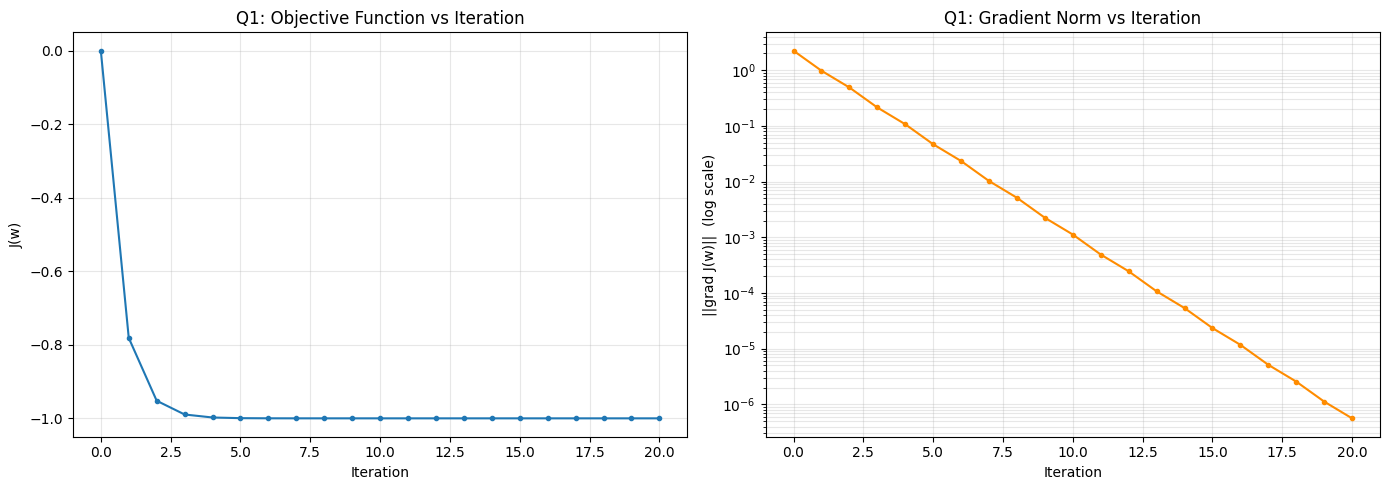

In [4]:
iters = np.arange(len(hist["J"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(iters, hist["J"], marker="o", markersize=3)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("J(w)")
axes[0].set_title("Q1: Objective Function vs Iteration")
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(iters, hist["grad_norm"], marker="o", markersize=3, color="darkorange")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("||grad J(w)||  (log scale)")
axes[1].set_title("Q1: Gradient Norm vs Iteration")
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

In [5]:
df_q1 = pd.DataFrame({
    "iter": iters,
    "w1": [w[0] for w in hist["w"]],
    "w2": [w[1] for w in hist["w"]],
    "J(w)": hist["J"],
    "grad_norm": hist["grad_norm"],
})
print("First and last few iterates:")
print(df_q1.head(6).to_string(index=False))
print("...")
print(df_q1.tail(3).to_string(index=False))

First and last few iterates:
 iter       w1       w2      J(w)  grad_norm
    0 0.000000 0.000000  0.000000   2.236068
    1 0.312500 0.625000 -0.781250   0.978280
    2 0.000000 0.781250 -0.952148   0.489140
    3 0.068359 0.917969 -0.989532   0.213999
    4 0.000000 0.952148 -0.997710   0.106999
    5 0.014954 0.982056 -0.999499   0.046812
...
 iter           w1       w2  J(w)    grad_norm
   18 2.117582e-22 0.999999  -1.0 2.564588e-06
   19 3.584120e-07 1.000000  -1.0 1.122007e-06
   20 2.117582e-22 1.000000  -1.0 5.610036e-07


---
## Q2: Gradient Descent and Adam

**Objective:** $g(w) = (w - 1.5)^2$, $w \in [1, 2]$

### Gradient Descent
$$w_{k+1} = w_k - \eta \, g'(w_k), \quad g'(w) = 2(w - 1.5)$$

Parameters: $\eta = 0.2$, $w_0 = 2$, 10 iterations

### Adam
$$
\begin{aligned}
m_t &= \rho_f \, m_{t-1} + (1 - \rho_f)\, \nabla g \\
v_t &= \rho \, v_{t-1} + (1 - \rho)\, (\nabla g)^2 \\
\hat{m}_t &= m_t / (1 - \rho_f^t) \\
\hat{v}_t &= v_t / (1 - \rho^t) \\
\alpha_t &= \eta \, \sqrt{1 - \rho^t} / (1 - \rho_f^t) \\
w_t &= w_{t-1} - \alpha_t \, m_t / (\sqrt{v_t} + \varepsilon)
\end{aligned}
$$

Parameters: $\eta = 0.2$, $\rho = 0.999$, $\rho_f = 0.9$, $w_0 = 2$, $\varepsilon = 10^{-8}$

In [6]:
def g(w):
    return (w - 1.5) ** 2


def grad_g(w):
    return 2 * (w - 1.5)


def gradient_descent(w0, lr, n_iter):
    w = w0
    rows = [(0, w, g(w))]
    for k in range(1, n_iter + 1):
        w = w - lr * grad_g(w)
        rows.append((k, w, g(w)))
    return pd.DataFrame(rows, columns=["k", "w_k", "g(w_k)"])


def adam(w0, lr, rho, rho_f, n_iter, eps=1e-8):
    w = w0
    m, v = 0.0, 0.0
    rows = [(0, w, np.nan, g(w))]
    for k in range(1, n_iter + 1):
        grad = grad_g(w)
        m = rho_f * m + (1 - rho_f) * grad
        v = rho * v + (1 - rho) * grad ** 2
        m_hat = m / (1 - rho_f ** k)
        v_hat = v / (1 - rho ** k)
        alpha_t = lr * np.sqrt(1 - rho ** k) / (1 - rho_f ** k)  # bias-corrected LR
        w = w - alpha_t * m / (np.sqrt(v) + eps)                 # equiv: lr*m_hat/(sqrt(v_hat)+eps)
        rows.append((k, w, alpha_t, g(w)))
    return pd.DataFrame(rows, columns=["k", "w_k", "alpha_k (A_k)", "g(w_k)"])

In [7]:
lr = 0.2
w0 = 2.0
n_iter = 10

print("=" * 60)
print("Q2.1/2.2: Gradient Descent")
print("=" * 60)
print("Update rule: w_{k+1} = w_k - 0.2 * 2*(w_k - 1.5) = w_k - 0.4*(w_k - 1.5)")
df_gd = gradient_descent(w0, lr, n_iter)
print(df_gd.to_string(index=False))

Q2.1/2.2: Gradient Descent
Update rule: w_{k+1} = w_k - 0.2 * 2*(w_k - 1.5) = w_k - 0.4*(w_k - 1.5)
 k      w_k   g(w_k)
 0 2.000000 0.250000
 1 1.800000 0.090000
 2 1.680000 0.032400
 3 1.608000 0.011664
 4 1.564800 0.004199
 5 1.538880 0.001512
 6 1.523328 0.000544
 7 1.513997 0.000196
 8 1.508398 0.000071
 9 1.505039 0.000025
10 1.503023 0.000009


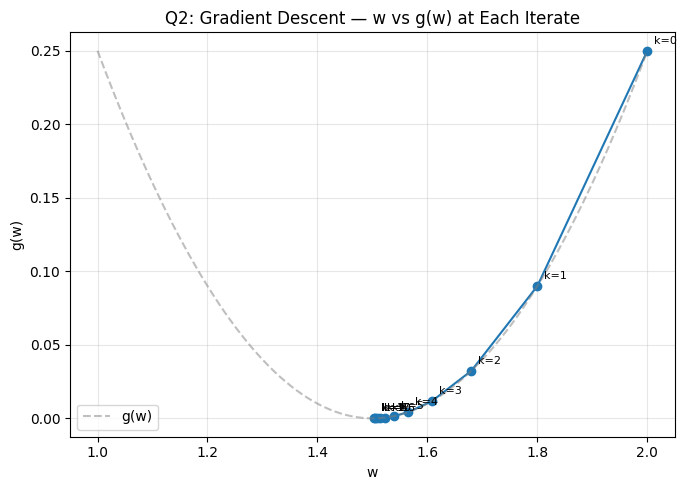

In [8]:
w_range = np.linspace(1, 2, 200)

plt.figure(figsize=(7, 5))
plt.plot(df_gd["w_k"], df_gd["g(w_k)"], marker="o")
for _, row in df_gd.iterrows():
    plt.annotate(f"k={int(row['k'])}", (row["w_k"], row["g(w_k)"]),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.plot(w_range, g(w_range), '--', color='gray', alpha=0.5, label='g(w)')
plt.xlabel("w")
plt.ylabel("g(w)")
plt.title("Q2: Gradient Descent — w vs g(w) at Each Iterate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
print("=" * 60)
print("Q2.3/2.4: Adam")
print("=" * 60)
rho, rho_f = 0.999, 0.9
df_adam = adam(w0, lr, rho, rho_f, n_iter)
print(df_adam.to_string(index=False))

Q2.3/2.4: Adam
 k      w_k  alpha_k (A_k)   g(w_k)
 0 2.000000            NaN 0.250000
 1 1.800000       0.063246 0.090000
 2 1.608502       0.047063 0.011773
 3 1.439583       0.040402 0.003650
 4 1.313724       0.036754 0.034699
 5 1.244792       0.034500 0.065131
 6 1.229383       0.033022 0.073233
 7 1.254674       0.032026 0.060185
 8 1.307569       0.031354 0.037030
 9 1.376950       0.030912 0.015141
10 1.453067       0.030638 0.002203


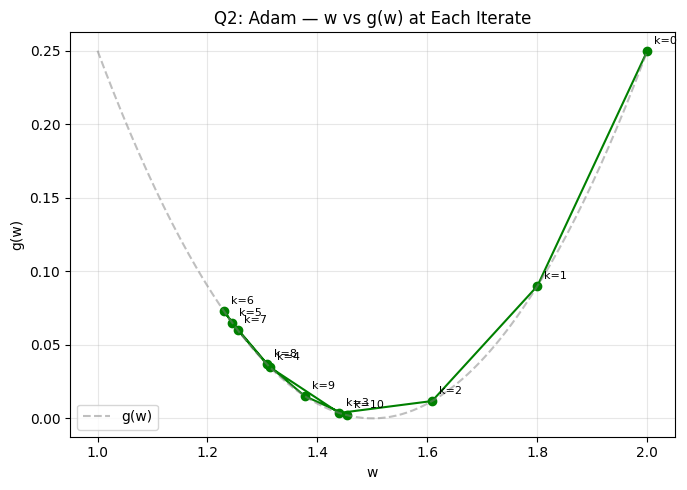

In [10]:
plt.figure(figsize=(7, 5))
plt.plot(df_adam["w_k"], df_adam["g(w_k)"], marker="o", color="green")
for _, row in df_adam.iterrows():
    plt.annotate(f"k={int(row['k'])}", (row["w_k"], row["g(w_k)"]),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.plot(w_range, g(w_range), '--', color='gray', alpha=0.5, label='g(w)')
plt.xlabel("w")
plt.ylabel("g(w)")
plt.title("Q2: Adam — w vs g(w) at Each Iterate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

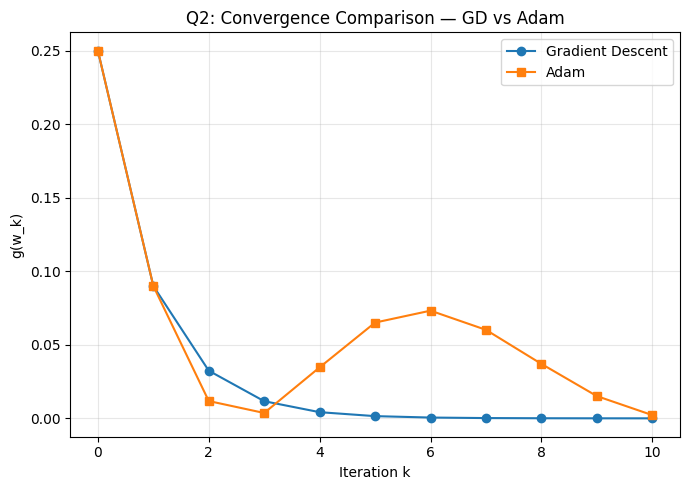

In [11]:
plt.figure(figsize=(7, 5))
plt.plot(df_gd["k"], df_gd["g(w_k)"], marker="o", label="Gradient Descent")
plt.plot(df_adam["k"], df_adam["g(w_k)"], marker="s", label="Adam")
plt.xlabel("Iteration k")
plt.ylabel("g(w_k)")
plt.title("Q2: Convergence Comparison — GD vs Adam")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Q3: AdaGrad and RMSProp

**Objective:** $f(x_1, x_2) = x_1^4 + 16\, x_2^4 - 8\, x_1 x_2$

**Partial derivatives:**
$$
\frac{\partial f}{\partial x_1} = 4x_1^3 - 8x_2, \qquad
\frac{\partial f}{\partial x_2} = 64x_2^3 - 8x_1
$$

### AdaGrad (per-coordinate)
$$
A_i \leftarrow A_i + \left(\frac{\partial f}{\partial x_i}\right)^2, \qquad
x_i \leftarrow x_i - \alpha \, \frac{\partial f / \partial x_i}{\sqrt{A_i + \varepsilon}}
$$

### RMSProp (per-coordinate)
$$
A_i \leftarrow \rho A_i + (1-\rho)\left(\frac{\partial f}{\partial x_i}\right)^2, \qquad
x_i \leftarrow x_i - \alpha \, \frac{\partial f / \partial x_i}{\sqrt{A_i + \varepsilon}}
$$

Both start at $(1,1)$, $\alpha = 0.01$, $\varepsilon = 0$, 20 iterations.

In [12]:
def f(x1, x2):
    return x1 ** 4 + 16 * x2 ** 4 - 8 * x1 * x2


def grad_f(x1, x2):
    df_dx1 = 4 * x1 ** 3 - 8 * x2
    df_dx2 = 64 * x2 ** 3 - 8 * x1
    return df_dx1, df_dx2


def adagrad(x0, alpha, n_iter, eps=0.0):
    x1, x2 = x0
    A1, A2 = 0.0, 0.0
    rows = []
    for k in range(1, n_iter + 1):
        fx1, fx2 = grad_f(x1, x2)
        A1 += fx1 ** 2
        A2 += fx2 ** 2
        x1 = x1 - alpha * fx1 / np.sqrt(A1 + eps)
        x2 = x2 - alpha * fx2 / np.sqrt(A2 + eps)
        rows.append((k, x1, x2, fx1, fx2, A1, A2, f(x1, x2)))
    cols = ["k", "x1", "x2", "f_x1", "f_x2", "A_x1", "A_x2", "f(x1,x2)"]
    return pd.DataFrame(rows, columns=cols)


def rmsprop(x0, alpha, rho, n_iter, eps=0.0):
    x1, x2 = x0
    A1, A2 = 0.0, 0.0
    rows = []
    for k in range(1, n_iter + 1):
        fx1, fx2 = grad_f(x1, x2)
        A1 = rho * A1 + (1 - rho) * fx1 ** 2
        A2 = rho * A2 + (1 - rho) * fx2 ** 2
        x1 = x1 - alpha * fx1 / np.sqrt(A1 + eps)
        x2 = x2 - alpha * fx2 / np.sqrt(A2 + eps)
        rows.append((k, x1, x2, fx1, fx2, A1, A2, f(x1, x2)))
    cols = ["k", "x1", "x2", "f_x1", "f_x2", "A_x1", "A_x2", "f(x1,x2)"]
    return pd.DataFrame(rows, columns=cols)

In [13]:
x0 = (1.0, 1.0)
alpha = 0.01
n_iter = 20

print("=" * 70)
print("Q3.2: AdaGrad  (alpha=0.01, eps=0)")
print("=" * 70)
df_ada = adagrad(x0, alpha, n_iter)
pd.set_option("display.float_format", lambda v: f"{v:.6f}")
print(df_ada.round(6).to_string(index=False))

Q3.2: AdaGrad  (alpha=0.01, eps=0)
 k       x1       x2      f_x1      f_x2       A_x1         A_x2  f(x1,x2)
 1 1.010000 0.990000 -4.000000 56.000000  16.000000  3136.000000  8.410940
 2 1.016886 0.983057 -3.798796 54.019136  30.430851  6054.067054  8.014933
 3 1.022413 0.977452 -3.658382 52.666727  43.814608  8827.851200  7.702837
 4 1.027134 0.972639 -3.544584 51.588349  56.378681 11489.208949  7.440254
 5 1.031306 0.968365 -3.446590 50.672050  68.257665 14056.865552  7.211216
 6 1.035072 0.964488 -3.359370 49.865783  79.543033 16543.461898  7.006792
 7 1.038524 0.960919 -3.280105 49.140419  90.302119 18958.242688  6.821401
 8 1.041722 0.957598 -3.207028 48.477727 100.587144 21308.332748  6.651278
 9 1.044709 0.954482 -3.138947 47.865413 110.440131 23599.430504  6.493748
10 1.047517 0.951540 -3.075013 47.294722 119.895834 25836.221235  6.346827
11 1.050171 0.948747 -3.014594 46.759163 128.983612 28022.640546  6.208998
12 1.052691 0.946084 -2.957208 46.253764 137.728692 30162.051262 

In [14]:
print("=" * 70)
print("Q3.3: RMSProp  (alpha=0.01, rho=0.9, eps=0)")
print("=" * 70)
df_rms = rmsprop(x0, alpha, rho=0.9, n_iter=n_iter)
print(df_rms.round(6).to_string(index=False))

Q3.3: RMSProp  (alpha=0.01, rho=0.9, eps=0)
 k       x1       x2      f_x1      f_x2     A_x1        A_x2  f(x1,x2)
 1 1.031623 0.968377 -4.000000 56.000000 1.600000  313.600000  7.210753
 2 1.052570 0.946735 -3.355418 49.865421 2.565883  530.896019  6.109292
 3 1.068947 0.929246 -2.909297 45.887683 3.155696  688.374366  5.289172
 4 1.082589 0.914139 -2.548241 42.802094 3.489479  802.738858  4.629449
 5 1.094317 0.900610 -2.237940 40.228850 3.641369  884.301010  4.075763
 6 1.104574 0.888219 -1.962982 37.996475 3.662562  940.244120  3.598421
 7 1.113625 0.876692 -1.715067 36.011110 3.590451  975.899714  3.179195
 8 1.121639 0.865847 -1.489239 34.215139 3.453189  995.377318  2.805984
 9 1.128728 0.855557 -1.282355 32.570376 3.272314 1001.922524  2.470276
10 1.134968 0.845729 -1.092338 31.050081 3.064403  998.141024  2.165823
11 1.140412 0.836292 -0.917786 29.634737 2.842196  986.148688  1.887877
12 1.145097 0.827191 -0.757735 28.309627 2.615392  967.677319  1.632726
13 1.149052 0.818384

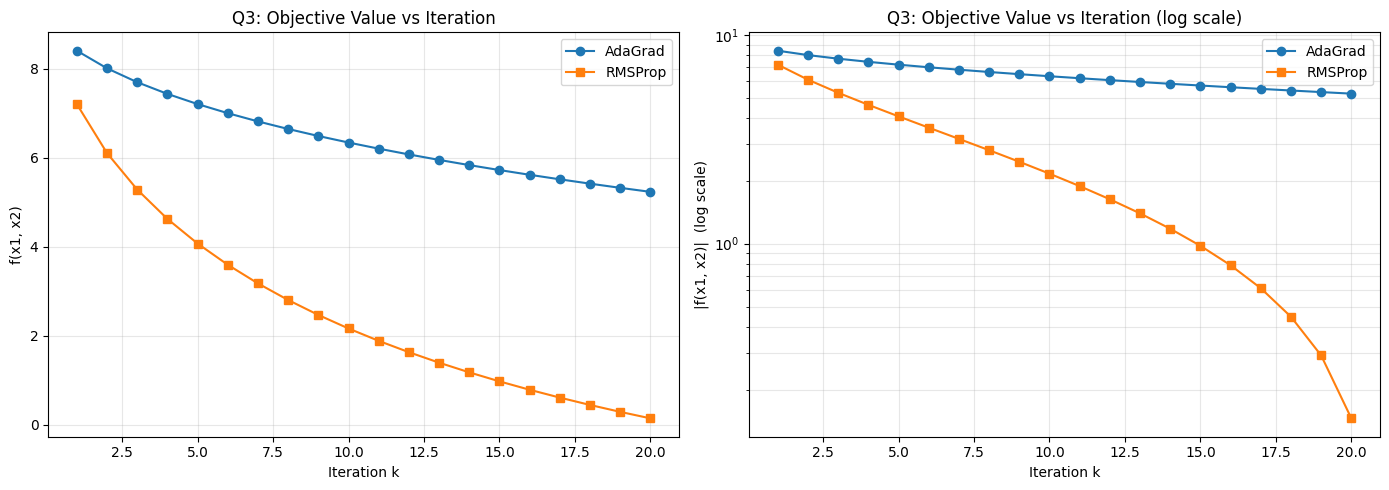

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_ada["k"], df_ada["f(x1,x2)"], marker="o", label="AdaGrad")
axes[0].plot(df_rms["k"], df_rms["f(x1,x2)"], marker="s", label="RMSProp")
axes[0].set_xlabel("Iteration k")
axes[0].set_ylabel("f(x1, x2)")
axes[0].set_title("Q3: Objective Value vs Iteration")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(df_ada["k"], df_ada["f(x1,x2)"].abs() + 1e-12, marker="o", label="AdaGrad")
axes[1].semilogy(df_rms["k"], df_rms["f(x1,x2)"].abs() + 1e-12, marker="s", label="RMSProp")
axes[1].set_xlabel("Iteration k")
axes[1].set_ylabel("|f(x1, x2)|  (log scale)")
axes[1].set_title("Q3: Objective Value vs Iteration (log scale)")
axes[1].legend()
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

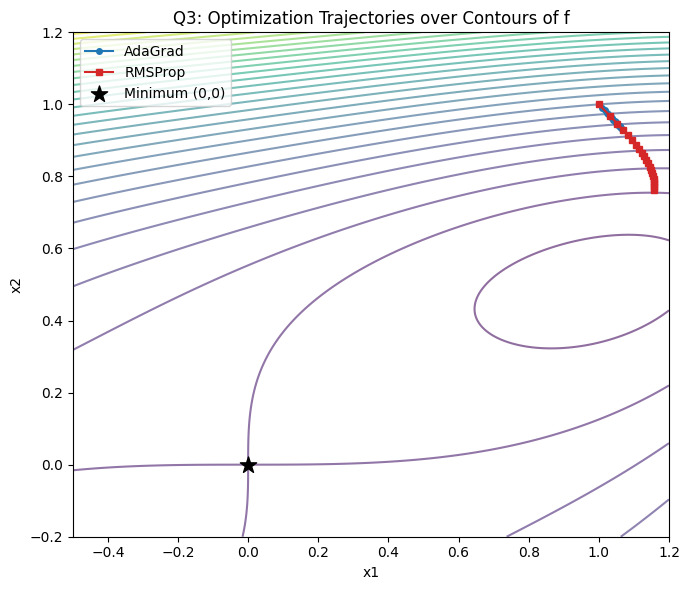


Final AdaGrad point: (np.float64(1.0694151928182263), np.float64(0.9280679040406749)) f = 5.237692979087319
Final RMSProp point: (np.float64(1.158030421372935), np.float64(0.7626376470766242)) f = 0.14555075515107152


In [16]:
# Trajectory plot in (x1, x2) plane with contours of f
x1g = np.linspace(-0.5, 1.2, 300)
x2g = np.linspace(-0.2, 1.2, 300)
X1, X2 = np.meshgrid(x1g, x2g)
F = f(X1, X2)

plt.figure(figsize=(7, 6))
cs = plt.contour(X1, X2, F, levels=30, cmap="viridis", alpha=0.6)
plt.plot(np.concatenate([[1.0], df_ada["x1"]]), np.concatenate([[1.0], df_ada["x2"]]),
          marker="o", color="tab:blue", label="AdaGrad", markersize=4)
plt.plot(np.concatenate([[1.0], df_rms["x1"]]), np.concatenate([[1.0], df_rms["x2"]]),
          marker="s", color="tab:red", label="RMSProp", markersize=4)
plt.scatter([0], [0], color="black", marker="*", s=150, zorder=5, label="Minimum (0,0)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Q3: Optimization Trajectories over Contours of f")
plt.legend()
plt.tight_layout()
plt.show()

print("\nFinal AdaGrad point:", (df_ada.iloc[-1]["x1"], df_ada.iloc[-1]["x2"]),
      "f =", df_ada.iloc[-1]["f(x1,x2)"])
print("Final RMSProp point:", (df_rms.iloc[-1]["x1"], df_rms.iloc[-1]["x2"]),
      "f =", df_rms.iloc[-1]["f(x1,x2)"])